In [1]:
%matplotlib widget
import matplotlib
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import os
import glob
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize


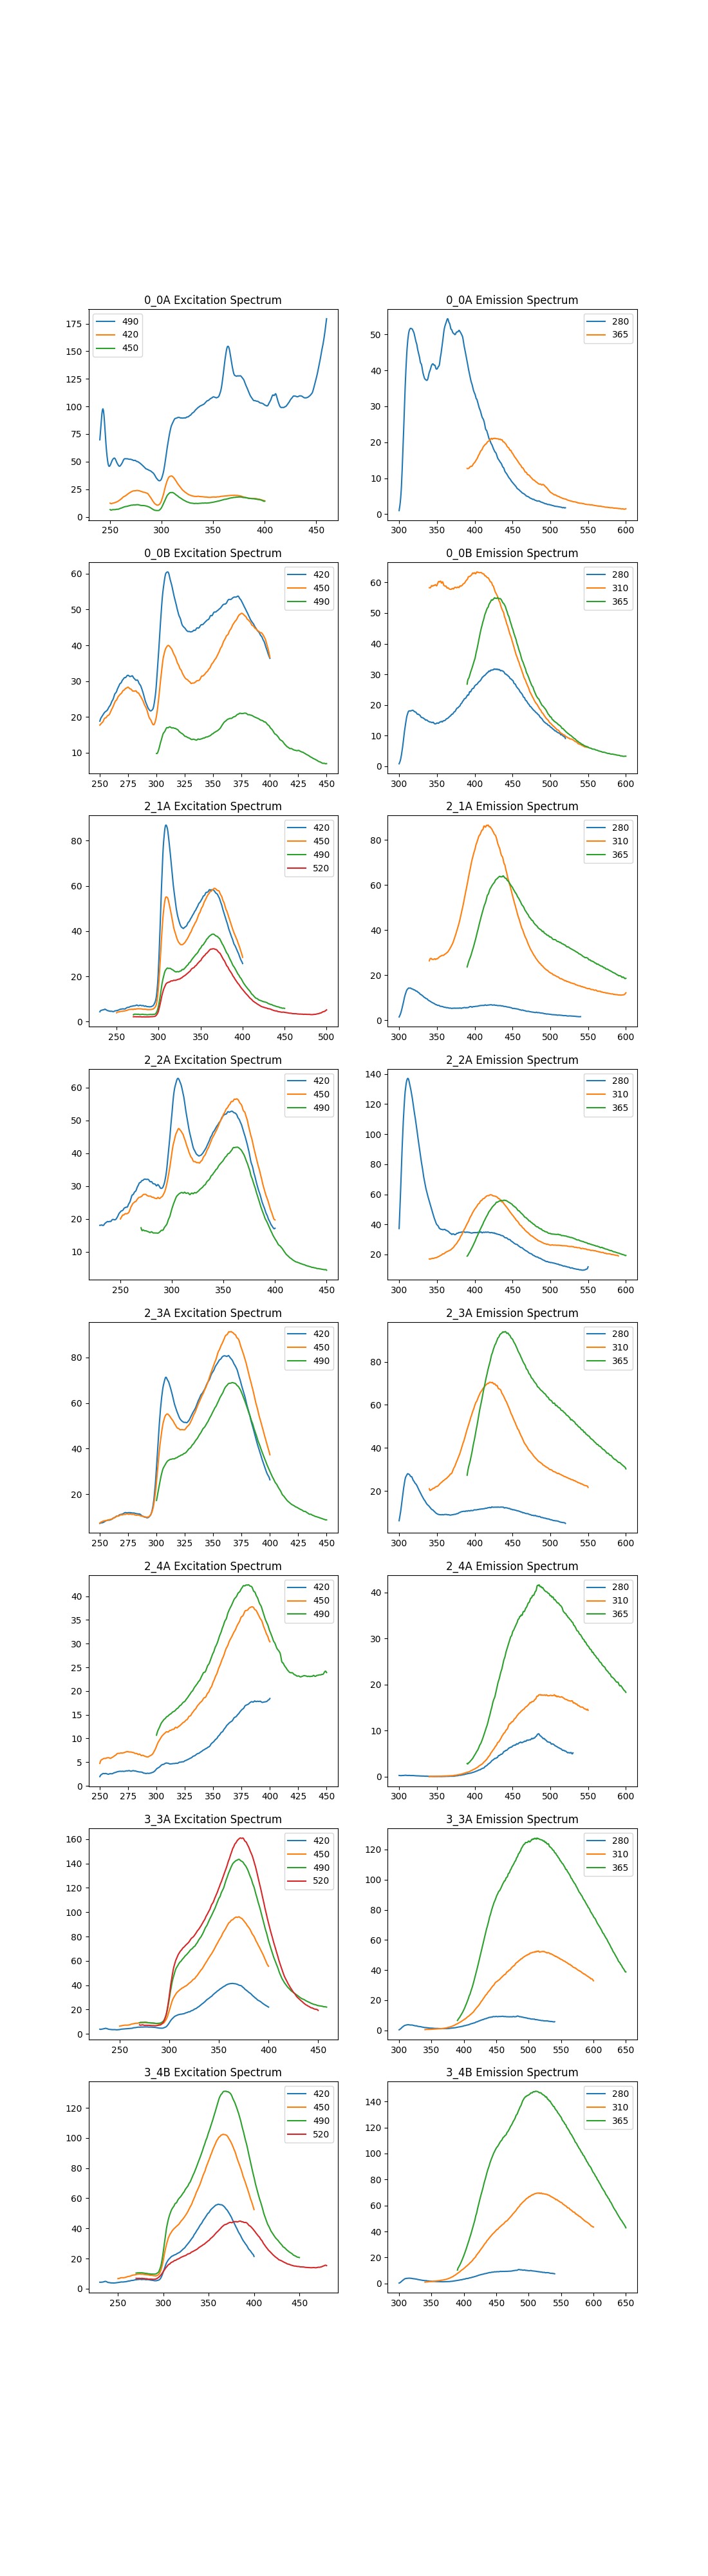

In [2]:
folder_path = './Photoluminescence/CdS_RT/No_Reflections'
dfs = []
scans = []

for root, dirs, files in os.walk(folder_path):
    for subdir in dirs:
        for file in glob.glob(f"./{folder_path}/{subdir}/*.sp"):
            df = pd.read_csv(file, skiprows = 54,names = ["Wavelength","I"], delimiter = "\t").assign(Run=os.path.basename(file).split(".")[0])
            with open(file,"r") as infile:
                params = infile.read().split("LS55")[1].split("#DATA")[0].split("\n")
                # print(params)
                ex_em = params[12]
                wavelength = int(float(params[1]))
                scan = "ex " + f"{wavelength}" if int(ex_em) == 1 else "em " + f"{wavelength}"
                # if scan not in scans:
                #     scans.append(scan)
                # else:
                #     scan_num = len([i for i in scans if scan in i])
                #     scan = scan + f" #{scan_num}"
                #     scans.append(scan)
            df["Scan"] = scan
            df["Sample"] = subdir
            # print(scan)
            dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
# print(df.head())
# fig, axes = plt.subplots(1,1)
# plt.plot(df["nm"],df["%T"])
# plt.show()

# fig = make_subplots(rows = len(pd.unique(df["Sample"])), cols = 1)
df = df.drop_duplicates(subset = ["Sample","Scan","Wavelength"],keep = "first")
df = df.sort_values(by = ["Sample","Wavelength","Scan"])
samples = pd.unique(df["Sample"])
# print(df)
fig, axes = plt.subplots(len(samples), 2, figsize = (11,len(samples)*5))
for i,sample in enumerate(samples):
    cut = df[df["Sample"]==sample]
    for scan in pd.unique(cut["Scan"]):
        dff = cut[cut["Scan"] == scan]
        # fig.append_trace(
        #     go.Scatter(
        #         x = cut["Wavelength"],
        #         y = cut["I"]
        #     ),
        # row = i+1,
        # col = 1
        # )
        if "em" in scan:
            xs = dff["Wavelength"].to_numpy()
            ys = dff["I"].to_numpy()
            axes[i][0].plot(xs,ys, label = scan.split()[1])
        else:
            xs = dff["Wavelength"].to_numpy()
            ys = dff["I"].to_numpy()
            if "ex 280" in scan:
                mask = xs<=550
                xs = xs[mask]
                ys = ys[mask]

            axes[i][1].plot(xs,ys, label = scan.split()[1])

    axes[i][0].legend()
    axes[i][1].legend()

    axes[i][0].set_title(f"{sample} Excitation Spectrum")
    axes[i][1].set_title(f"{sample} Emission Spectrum")
            # color = "Scan", template = "simple_white"))
plt.show()

C:\Users\decla\AppData\Local\Temp\ipykernel_26172\1084903709.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("copper")  # or 'plasma', 'coolwarm', etc.


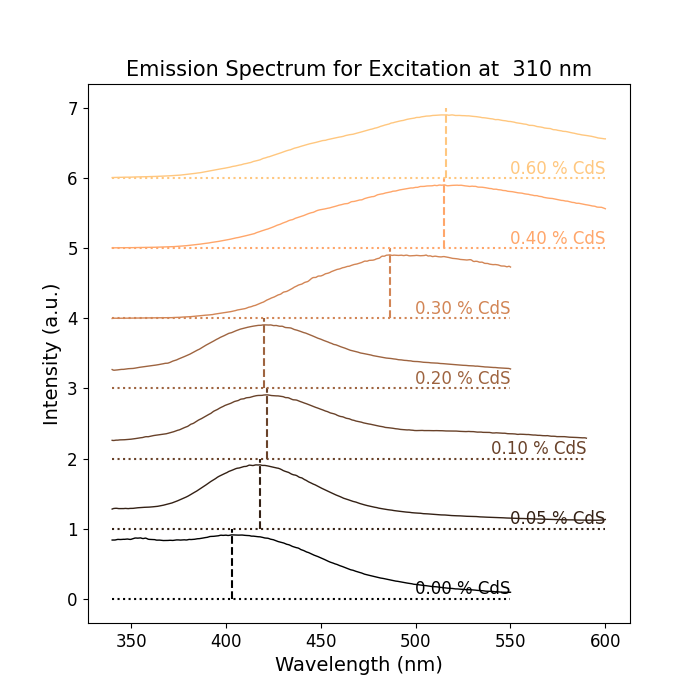

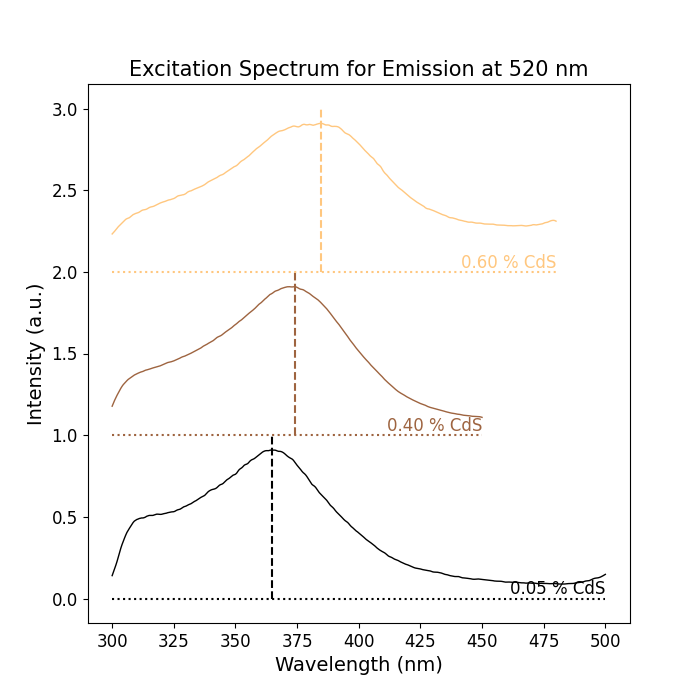

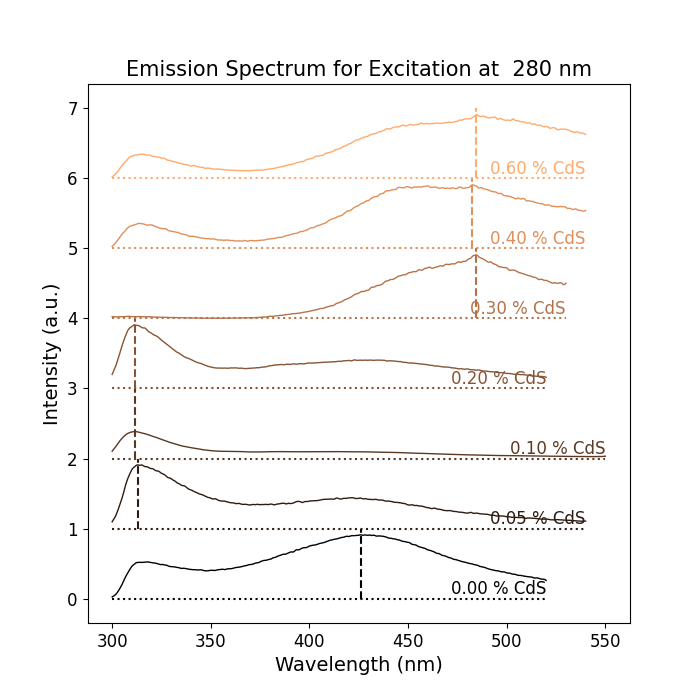

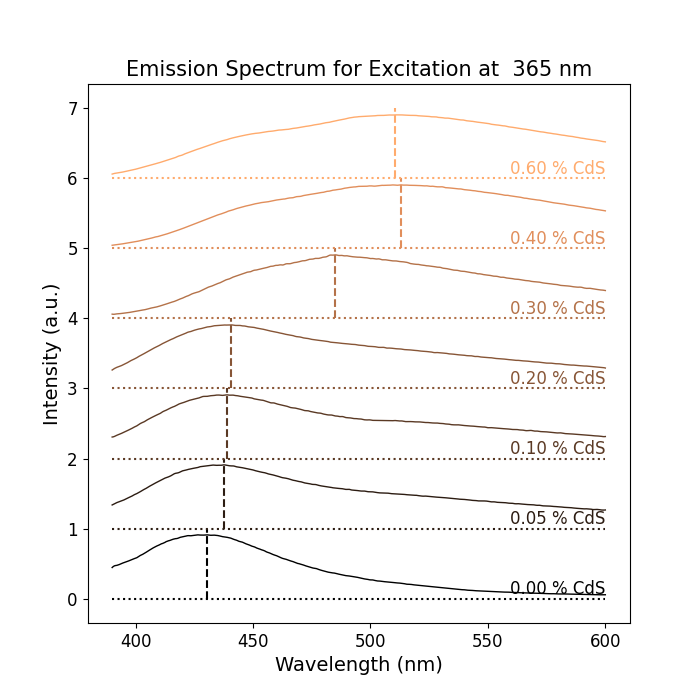

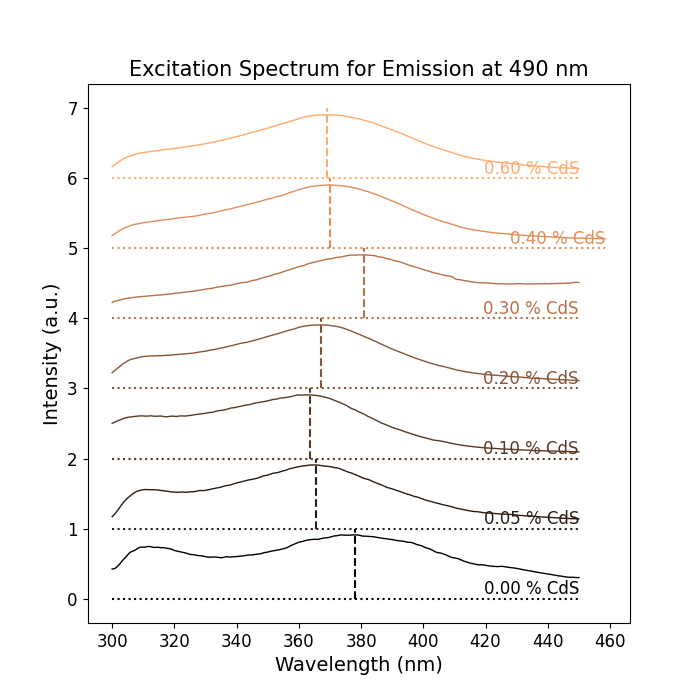

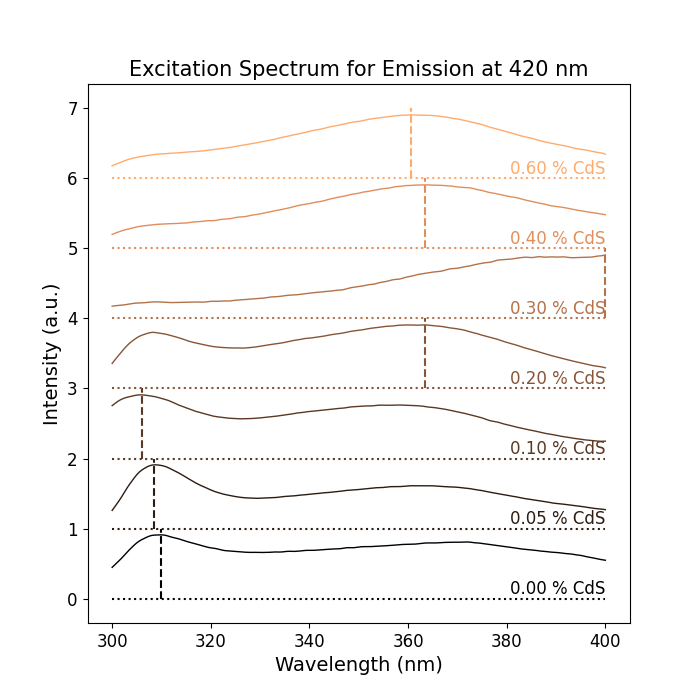

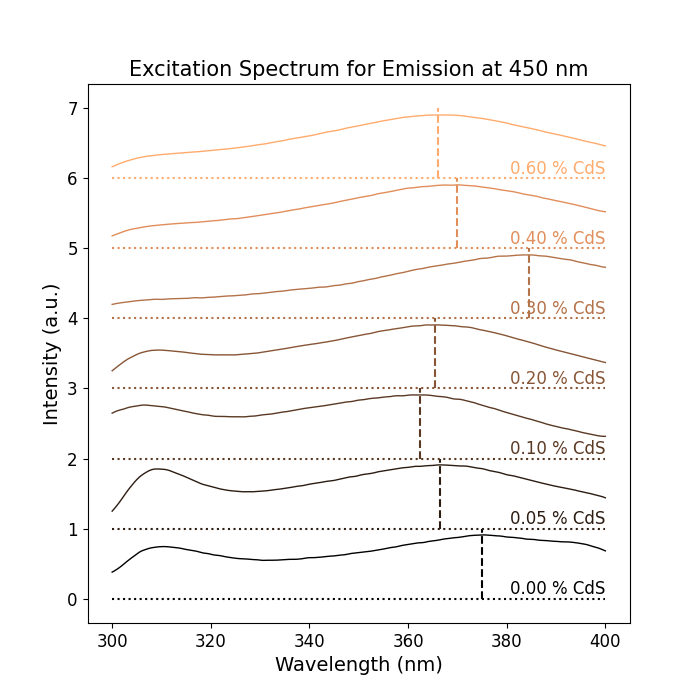

In [11]:
cds = {"0_0B":"0.00","2_1A":"0.05","2_2A":"0.10","2_3A":"0.20", "2_4A":"0.30", "2_1B":"0.05","2_2B":"0.10","2_3B":"0.20", "2_4B":"0.30","3_3A":"0.40","3_4B":"0.60"}
cds_b = {"2_1B":"0.05","2_2B":"0.10","2_3B":"0.20", "2_4B":"0.30"}

for scan_type in ["ex","em"]:
    dfff = df[df["Scan"].str.contains(scan_type)]
    scans = pd.unique(dfff["Scan"])

    for i,scan in enumerate(scans):
        cut = dfff[dfff["Scan"]==scan]
        plotted_scans = []
        fig, axes = plt.subplots(1,1, figsize = (7,7))
        n = 0
        for j,sample in enumerate(pd.unique(cut["Sample"])):
            num_lines = len(pd.unique(cut["Sample"]))
            cmap = get_cmap("copper")  # or 'plasma', 'coolwarm', etc.
            norm = Normalize(vmin=0, vmax=num_lines-1)
            if sample!="0_0A":
                dff = cut[cut["Sample"] == sample]
                # axes[i].plot(dff["Wavelength"],dff["I"]/max(dff["I"]), label = sample)
                xs = dff["Wavelength"].to_numpy()
                ys = dff["I"].to_numpy()
                if max(xs) >= 600 or min(xs)<=300:
                    mask = (xs<=600)&(xs>=300)
                    xs = xs[mask]
                    ys = ys[mask]

                ys /= (max(ys)*1.1)
                ys+=n

                if "ex 280" in scan:
                    mask = xs<=550
                    xs = xs[mask]
                    ys = ys[mask]

                axes.plot(xs,ys, label = cds[sample], color=cmap(norm(n)), lw = 1, alpha = 1)
                axes.text(max(xs),n, f"{cds[sample]} % CdS", color=cmap(norm(n)), fontsize = 12, va = "bottom", ha = "right")
                axes.vlines(xs[np.argmax(ys)],n,n+1, ls = "--", color=cmap(norm(n)))
                axes.hlines(n,xs[0],xs[-1], ls = ":", color=cmap(norm(n)))

                n+=1
        # axes[i].set_yscale("log")
        # plt.legend(title = "% CdS", title_fontsize = 14, fontsize = 12, ncols = 3)
        plt.xlabel("Wavelength (nm)", fontsize = 14)
        plt.ylabel("Intensity (a.u.)", fontsize = 14)
        plt.xticks(fontsize = 12)
        plt.yticks(fontsize = 12)
        # print(plotted_scans)

        axes.set_title(f"{scan.replace("ex","Emission Spectrum for Excitation at ").replace("em", "Excitation Spectrum for Emission at")} nm", fontsize = 15)
    plt.show()
